In [17]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import io
from PIL import Image
from dotenv import load_dotenv
import os
load_dotenv()
import requests
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
# Libraries for Slicing Aided Hyper Inference (SAHI)
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import numpy as np


Requesting high-resolution asset from Earth Engine...
Saved crisp 1-meter resolution image as 'airport_patch_highres.tif'
Applying Contrast Limited Adaptive Histogram Equalization (CLAHE)...
Loading satellite-optimized weights...
Running Slicing Aided Hyper Inference (SAHI) over the map grid...
Performing prediction on 9 slices.
Inference complete! Spotted 11 confirmed aircraft.


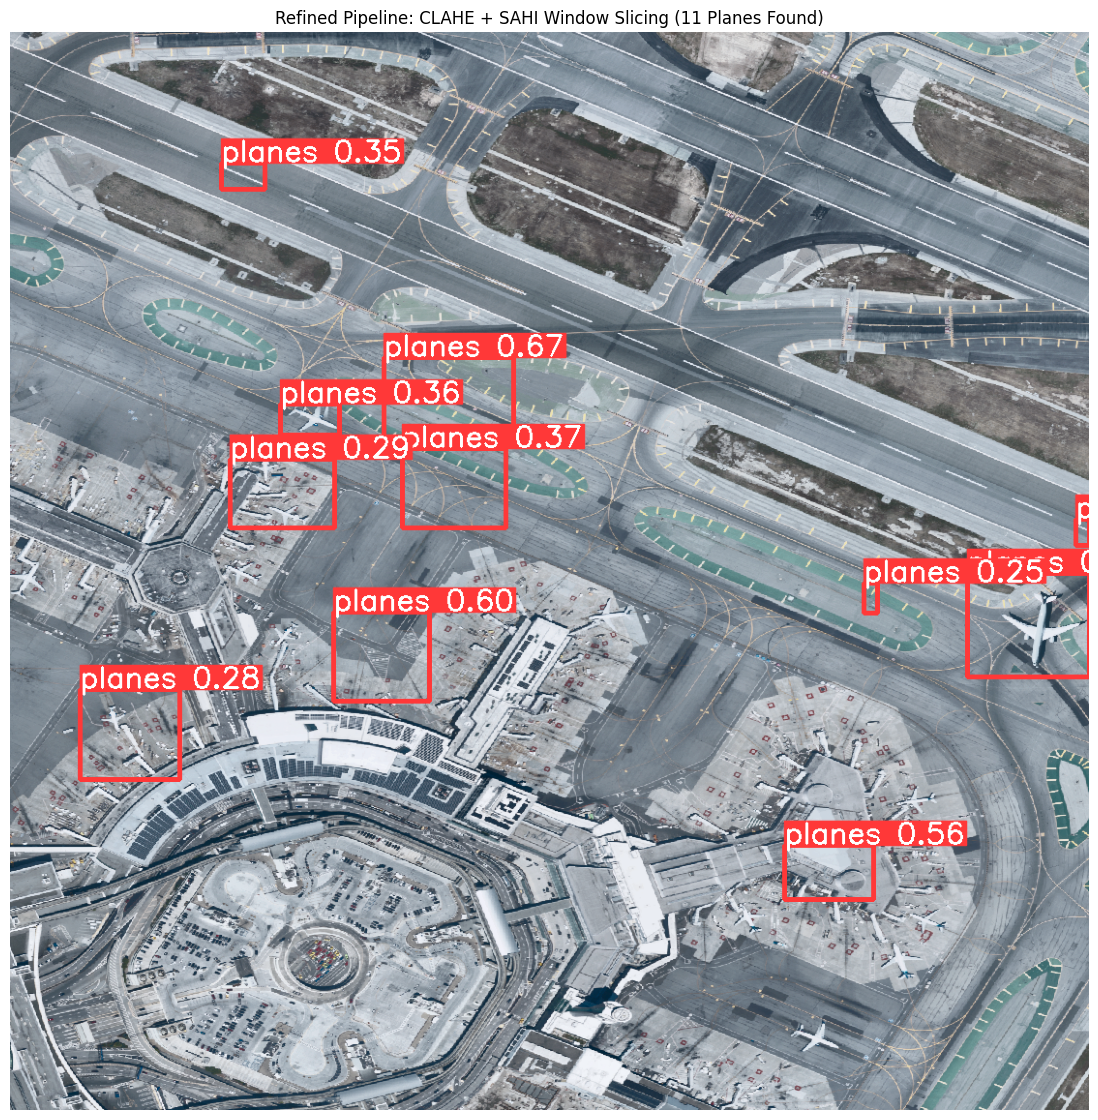

In [18]:

load_dotenv()
ee.Initialize(project=os.getenv('GOOGLE_PROJECT_ID'))

# 2. Fetch High-Resolution (1-meter) Aerial Data from USDA NAIP
def fetch_high_res_airport_patch(polygon_coords):
    roi = ee.Geometry.Polygon(polygon_coords)
    
    # NAIP imagery features 1-meter resolution across the United States
    raw_image = (ee.ImageCollection('USDA/NAIP/DOQQ')
                 .filterBounds(roi)
                 .filterDate('2021-01-01', '2025-12-31')
                 .mosaic()                 
                 .select(['R', 'G', 'B'])) 
             
    visualized_image = raw_image.visualize(min=0, max=255)
    
    url = visualized_image.getDownloadURL({
        'scale': 1,          # 1 meter per pixel (10x sharper than Sentinel-2)
        'crs': 'EPSG:4326',  
        'region': roi,
        'format': 'GEO_TIFF' 
    })
    return url

# Bounding coordinates for San Francisco International Airport (SFO)
polygon_coords = [[[-122.389, 37.615], [-122.389, 37.625], [-122.379, 37.625], [-122.379, 37.615]]]

print("Requesting high-resolution asset from Earth Engine...")
url = fetch_high_res_airport_patch(polygon_coords)

# Download image locally
response = requests.get(url)
if response.status_code == 200:
    with open('airport_patch_highres.tif', 'wb') as f:
        f.write(response.content)
    print("Saved crisp 1-meter resolution image as 'airport_patch_highres.tif'")
else:
    print("Download failed. Status code:", response.status_code)

# 3. Load the 1m image and drop potential Alpha channels
img = Image.open('airport_patch_highres.tif')
img_array = np.array(img)[..., :3]  

# ----------------------------------------------------------------
# IMAGE ENHANCEMENT BLOCK: CLAHE CONTRAST STRETCH
# ----------------------------------------------------------------
print("Applying Contrast Limited Adaptive Histogram Equalization (CLAHE)...")
# Convert RGB array to LAB color space to isolate illumination (L channel)
lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2Lab)
l_channel, a_channel, b_channel = cv2.split(lab)

# Create and apply CLAHE to optimize wing boundaries and tarmac contrast locally
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl_optimized = clahe.apply(l_channel)

# Merge channels back together and return to standard RGB spectrum
enhanced_lab = cv2.merge((cl_optimized, a_channel, b_channel))
enhanced_img_array = cv2.cvtColor(enhanced_lab, cv2.COLOR_Lab2RGB)


# 4. Download and Load Satellite-Specific YOLO Weights from Hugging Face
print("Loading satellite-optimized weights...")
satellite_model_path = hf_hub_download(
    repo_id="keremberke/yolov8s-plane-detection", 
    filename="best.pt"
)

# Wrap your YOLO model inside SAHI's standard detection interface
detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=satellite_model_path,
    confidence_threshold=0.22,  # Balanced threshold (stops tarmac hallucinations)
    device="cpu"                # Change to "cuda" if running with an active GPU
)

# ----------------------------------------------------------------
# SLICED INFERENCE BLOCK: PREVENT RESIZING PIXEL DEGRADATION
# ----------------------------------------------------------------
print("Running Slicing Aided Hyper Inference (SAHI) over the map grid...")
sahi_result = get_sliced_prediction(
    enhanced_img_array,        # Use the contrast-maximized image matrix
    detection_model,
    slice_height=512,          # Look at the image via sharp 512x512 viewports
    slice_width=512,
    overlap_height_ratio=0.25, # 25% overlap ensures planes cut by grid lines are preserved
    overlap_width_ratio=0.25
)

# Export the stitched bounding box array locally
sahi_result.export_visuals(export_dir=".", file_name="sahi_refined_output")
print(f"Inference complete! Spotted {len(sahi_result.object_prediction_list)} confirmed aircraft.")

# 5. Display the final high-definition result in your notebook
final_output_plot = Image.open("sahi_refined_output.png")

plt.figure(figsize=(14, 14))
plt.imshow(final_output_plot)
plt.title(f"Refined Pipeline: CLAHE + SAHI Window Slicing ({len(sahi_result.object_prediction_list)} Planes Found)")
plt.axis('off')
plt.show()
